BUILDING A BASIC CHATBOT WITH LANGGRAPH (GRAPH API)

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [ ]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="openai/gpt-oss-20b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.5', 'langchain': '1.4.3'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001E710404980>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E7104052B0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

1) Simple Chatbot

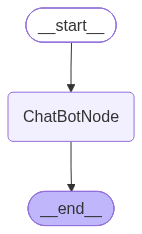

In [9]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from IPython.display import display, Image

class State(TypedDict):
    messages : Annotated[list,add_messages]

def chatbot(state : State):
    return {"messages" : [llm.invoke(state["messages"])]}

graph_builder = StateGraph(State)
graph_builder.add_node("ChatBotNode",chatbot)
graph_builder.add_edge(START,"ChatBotNode")
graph_builder.add_edge("ChatBotNode",END)
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
response = graph.invoke({"messages" : "Hi! How are you? I hope you are doing well."})
response["messages"]

[HumanMessage(content='Hi! How are you? I hope you are doing well.', additional_kwargs={}, response_metadata={}, id='cfbd2ba4-3c0b-4331-adb6-34648437131d'),
 AIMessage(content='Hi there! I’m doing great—thanks for asking. How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond in a friendly manner, acknowledging. The user says "Hi! How are you? I hope you are doing well." So we respond warmly. Probably keep it short.'}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 84, 'total_tokens': 151, 'completion_time': 0.084211919, 'completion_tokens_details': {'reasoning_tokens': 39}, 'prompt_time': 0.003947762, 'prompt_tokens_details': None, 'queue_time': 0.047982254, 'total_time': 0.088159681}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_c5a89987dc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0f2da-ae59-7b61-9a9c-719054e692fc-0', tool_calls=[],

2. Simple Chatbot with Tools

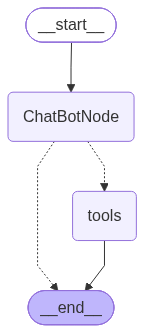

In [ ]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_tavily import TavilySearch
from IPython.display import display, Image

class State(TypedDict):
    messages : Annotated[list,add_messages]

def tool1(city : str) -> str:
    """Gives the current weather of the given city"""
    return f"The weather in {city} is clear and pleasant."

tool2 = TavilySearch(max_results=2)

tool = [tool1,tool2]

llm_with_tools = llm.bind_tools(tool)

def chatbot(state : State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

graph_builder = StateGraph(State)
graph_builder.add_node("ChatBotNode",chatbot)
graph_builder.add_node("tools",ToolNode(tool))
graph_builder.add_edge(START,"ChatBotNode")
graph_builder.add_conditional_edges("ChatBotNode",tools_condition)
graph_builder.add_edge("tools",END)
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
response = graph.invoke({"messages" : "What is the latest AI news?"})
response["messages"]

[HumanMessage(content='What is the latest AI news?', additional_kwargs={}, response_metadata={}, id='27c773f0-61bd-4200-81f6-3a0b59f13d3e'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the latest AI news?" They want up-to-date information. The assistant should use the search tool. Let\'s search.', 'tool_calls': [{'id': 'fc_e9032a06-7c25-4a68-9c92-604ec2c5bb12', 'function': {'arguments': '{"query":"latest AI news 2026","search_depth":"advanced","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 374, 'total_tokens': 444, 'completion_time': 0.103023012, 'completion_tokens_details': {'reasoning_tokens': 31}, 'prompt_time': 0.021279491, 'prompt_tokens_details': None, 'queue_time': 0.32984643, 'total_time': 0.124302503}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_66f3850a1a', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'lo

In [27]:
response = graph.invoke({"messages" : "What is the weather in Mumbai and then give me the latest AI news?"})
response["messages"]

[HumanMessage(content='What is the weather in Mumbai and then give me the latest AI news?', additional_kwargs={}, response_metadata={}, id='c7e09e9d-d1c3-4d0f-ab22-17da6090d000'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants weather in Mumbai and latest AI news. Need current weather: real-time. We need to browse. Use tavily_search for weather. Also for AI news. Use search. Then provide answer.', 'tool_calls': [{'id': 'fc_6dc47357-48d0-45fb-b6c7-b2773fb92ac0', 'function': {'arguments': '{"query":"weather in Mumbai today","search_depth":"basic"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 382, 'total_tokens': 457, 'completion_time': 0.105991315, 'completion_tokens_details': {'reasoning_tokens': 42}, 'prompt_time': 0.019697321, 'prompt_tokens_details': None, 'queue_time': 0.332433992, 'total_time': 0.125688636}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_107

3. ReACT Agent Architechture

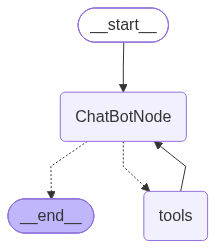

In [28]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_tavily import TavilySearch
from IPython.display import display, Image

class State(TypedDict):
    messages : Annotated[list,add_messages]

def tool1(city : str) -> str:
    """Gives the current weather of the given city"""
    return f"The weather in {city} is clear and pleasant."

tool2 = TavilySearch(max_results=2)

tool = [tool1,tool2]

llm_with_tools = llm.bind_tools(tool)

def chatbot(state : State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

graph_builder = StateGraph(State)
graph_builder.add_node("ChatBotNode",chatbot)
graph_builder.add_node("tools",ToolNode(tool))
graph_builder.add_edge(START,"ChatBotNode")
graph_builder.add_conditional_edges("ChatBotNode",tools_condition)
graph_builder.add_edge("tools","ChatBotNode")
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
response = graph.invoke({"messages" : "What is the weather in Mumbai and then give me the latest AI news?"})
response["messages"]

[HumanMessage(content='What is the weather in Mumbai and then give me the latest AI news?', additional_kwargs={}, response_metadata={}, id='b0a1038b-2965-4607-9a8c-b4df3831041a'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to get current weather in Mumbai. Use tool1. Then give latest AI news. For latest AI news, we need to search. Use tavily_search. Probably query "latest AI news" or "AI news 2026". We\'ll do a search.', 'tool_calls': [{'id': 'fc_a28ccbb5-4cf4-4ecb-a496-2b1c7a792a87', 'function': {'arguments': '{"query":"latest AI news 2026","search_depth":"advanced","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 99, 'prompt_tokens': 352, 'total_tokens': 451, 'completion_time': 0.101444954, 'completion_tokens_details': {'reasoning_tokens': 55}, 'prompt_time': 0.020411017, 'prompt_tokens_details': None, 'queue_time': 0.309770549, 'total_time': 0.121855971}, 'model_

4. ReACT Agent with Memory

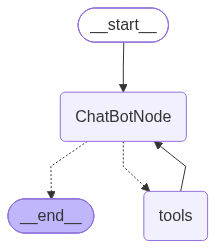

In [31]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver
from langchain_tavily import TavilySearch
from IPython.display import display, Image

class State(TypedDict):
    messages : Annotated[list,add_messages]

def tool1(city : str) -> str:
    """Gives the current weather of the given city"""
    return f"The weather in {city} is clear and pleasant."

tool2 = TavilySearch(max_results=2)

tool = [tool1,tool2]

llm_with_tools = llm.bind_tools(tool)

def chatbot(state : State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

graph_builder = StateGraph(State)
graph_builder.add_node("ChatBotNode",chatbot)
graph_builder.add_node("tools",ToolNode(tool))
graph_builder.add_edge(START,"ChatBotNode")
graph_builder.add_conditional_edges("ChatBotNode",tools_condition)
graph_builder.add_edge("tools","ChatBotNode")
graph = graph_builder.compile(checkpointer=InMemorySaver())
display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
config = {"configurable" : {"thread_id" : "thread"}}

In [ ]:
response = graph.invoke({"messages" : "Hello! My name is Nupur."},config)
response

{'messages': [HumanMessage(content='Hello! My name is Nupur. How are you?', additional_kwargs={}, response_metadata={}, id='3ad7fb16-b48b-47b4-84dd-f7dfcb1fe931'),
  AIMessage(content='Hi Nupur! I’m doing great—thanks for asking. How can I help you today?', additional_kwargs={'reasoning_content': 'User: "Hello! My name is Nupur. How are you?" They greet. We respond friendly. No tools needed.'}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 350, 'total_tokens': 408, 'completion_time': 0.062623424, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.021973468, 'prompt_tokens_details': None, 'queue_time': 0.351609944, 'total_time': 0.084596892}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e2cb7a84ec', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0f36f-53d7-7871-a812-1d16ccb4d7fb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 3

In [36]:
response = graph.invoke({"messages" : "How are you?"},config)
response

{'messages': [HumanMessage(content='Hello! My name is Nupur. How are you?', additional_kwargs={}, response_metadata={}, id='3ad7fb16-b48b-47b4-84dd-f7dfcb1fe931'),
  AIMessage(content='Hi Nupur! I’m doing great—thanks for asking. How can I help you today?', additional_kwargs={'reasoning_content': 'User: "Hello! My name is Nupur. How are you?" They greet. We respond friendly. No tools needed.'}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 350, 'total_tokens': 408, 'completion_time': 0.062623424, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.021973468, 'prompt_tokens_details': None, 'queue_time': 0.351609944, 'total_time': 0.084596892}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e2cb7a84ec', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0f36f-53d7-7871-a812-1d16ccb4d7fb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 3

In [38]:
response = graph.invoke({"messages" : "Do you know my name?"},config)
response["messages"]

[HumanMessage(content='Hello! My name is Nupur. How are you?', additional_kwargs={}, response_metadata={}, id='3ad7fb16-b48b-47b4-84dd-f7dfcb1fe931'),
 AIMessage(content='Hi Nupur! I’m doing great—thanks for asking. How can I help you today?', additional_kwargs={'reasoning_content': 'User: "Hello! My name is Nupur. How are you?" They greet. We respond friendly. No tools needed.'}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 350, 'total_tokens': 408, 'completion_time': 0.062623424, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.021973468, 'prompt_tokens_details': None, 'queue_time': 0.351609944, 'total_time': 0.084596892}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e2cb7a84ec', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0f36f-53d7-7871-a812-1d16ccb4d7fb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 350, 'output_to

STREAMING

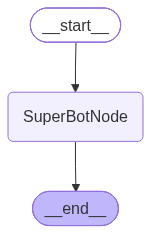

In [41]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import display, Image

class State(TypedDict):
    messages : Annotated[list,add_messages]

def chatbot(state : State):
    return {"messages" : [llm.invoke(state["messages"])]}

graph_builder = StateGraph(State)
graph_builder.add_node("SuperBotNode",chatbot)
graph_builder.add_edge(START,"SuperBotNode")
graph_builder.add_edge("SuperBotNode",END)
graph = graph_builder.compile(checkpointer=InMemorySaver())
display(Image(graph.get_graph().draw_mermaid_png()))

.stream() and .astream() are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state:- 

1. values : This streams the full state of the graph after each node is called.

2. updates : This streams updates to the state of the graph after each node is called.

In [44]:
config = {"configurable" : {"thread_id" : "1"}}

for chunk in graph.stream({"messages" : "Hello! My name is Nupur."},config,stream_mode="values"):
    print(chunk)

for chunk in graph.stream({"messages" : "How are you? Do you know my name?"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hello! My name is Nupur.', additional_kwargs={}, response_metadata={}, id='df199130-e069-420b-bdd6-6e5c86766a26'), AIMessage(content='Hello Nupur! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 80, 'total_tokens': 110, 'completion_time': 0.032915987, 'completion_tokens_details': {'reasoning_tokens': 7}, 'prompt_time': 0.016994866, 'prompt_tokens_details': None, 'queue_time': 0.335721168, 'total_time': 0.049910853}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_639a5351c8', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0f710-fb02-7a31-a7f8-76225ba79003-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 80, 'output_tokens': 30, 'total_tokens': 110, 'output_token_details': {'reasoning': 7}}), HumanMessage(content='Hel

In [45]:
config = {"configurable" : {"thread_id" : "2"}}

for chunk in graph.stream({"messages" : "Hello! My name is Nupur."},config,stream_mode="updates"):
    print(chunk)

for chunk in graph.stream({"messages" : "How are you? Do you know my name?"},config,stream_mode="updates"):
    print(chunk)

{'SuperBotNode': {'messages': [AIMessage(content='Hi Nupur! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond in a friendly manner. Probably ask how we can help.'}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 80, 'total_tokens': 120, 'completion_time': 0.044559645, 'completion_tokens_details': {'reasoning_tokens': 17}, 'prompt_time': 0.003806449, 'prompt_tokens_details': None, 'queue_time': 0.628855931, 'total_time': 0.048366094}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_63473661d7', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0f714-a5b6-7e20-8b3c-b541a235b66b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 80, 'output_tokens': 40, 'total_tokens': 120, 'output_token_details': {'reasoning': 17}})]}}
{'SuperBotNode': {'messages': [AIMessage(content='I’m just a virtual assistant, so I don’t have feelin

In [ ]:
config = {"configurable" : {"thread_id" : "3"}}

async for event in graph.astream_events({"messages" : "Hello! My name is Nupur."},config):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hello! My name is Nupur.'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a0f716-b731-74e1-b515-e3c5b9a1be68', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hello! My name is Nupur.', additional_kwargs={}, response_metadata={}, id='0db96f4e-c967-463e-acc2-9ec68f95037c')]}}, 'name': 'SuperBotNode', 'tags': ['graph:step:1'], 'run_id': '01a0f716-b746-7183-af2a-bc0984c405af', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBotNode', 'langgraph_triggers': ('branch:to:SuperBotNode',), 'langgraph_path': ('__pregel_pull', 'SuperBotNode'), 'langgraph_checkpoint_ns': 'SuperBotNode:8749edd5-3898-8621-869d-a707836638b0'}, 'parent_ids': ['01a0f716-b731-74e1-b515-e3c5b9a1be68']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='H